### 학습목표
- RNN 학습방법에 대해서 알아보자
- 시계열 데이터학습하여 예측하는 방법에 대해서 알아보자
- keras 의 SimpleRNN() 을 활용해보자

### RNN (Recurrent Nural Network) 순환신경망
- 순환하는 신경망으로 앞서 입력받은 데이터의 연산결과를 잠시 기억 -> 다음 학습시 사용하여 시계열 데이터 연산에 활용
- 이전데이터가 다음데이터 예측에 영향을 미치면서 학습

### Char -> 알파벳 한글자 단위로 학습
- 알파벳 4개의 글자가 들어가면 마지막 글자를 맞추는 모델을 만들어보자
- hello, apple, happy, drink, house
- 단어사전 만들기~
  - h,e,l,o,a,p,y,d,r,i,n,k,u,s (14개)
  - 모델이 학습하기 위하여 현재 사용할 단어들의 묶음을 생성
  - 지금 사용할 단어들만 단어사전을 만들어보자!!

In [1]:
import numpy as np

In [2]:
# 입력데이터 생성
# 앞의 4개의 알파벳 -> 학습용 문제 데이터
# h -> [1,0,0,0,0,0,0,0,0,0,0,0,0,0]
# e -> [0,1,0,0,0,0,0,0,0,0,0,0,0,0]
# X = np.array([[h,e,l,l],
#               [a,p,p,l],
#               [h,a,p,p],
#               [d,r,i,n],
#               [h,o,u,s]])
X = np.array([
    [[1,0,0,0,0,0,0,0,0,0,0,0,0,0],[0,1,0,0,0,0,0,0,0,0,0,0,0,0],[0,0,1,0,0,0,0,0,0,0,0,0,0,0],[0,0,1,0,0,0,0,0,0,0,0,0,0,0]],
    [[0,0,0,0,1,0,0,0,0,0,0,0,0,0],[0,0,0,0,0,1,0,0,0,0,0,0,0,0],[0,0,0,0,0,1,0,0,0,0,0,0,0,0],[0,0,1,0,0,0,0,0,0,0,0,0,0,0]],
    [[1,0,0,0,0,0,0,0,0,0,0,0,0,0],[0,0,0,0,1,0,0,0,0,0,0,0,0,0],[0,0,0,0,0,1,0,0,0,0,0,0,0,0],[0,0,0,0,0,1,0,0,0,0,0,0,0,0]],
    [[0,0,0,0,0,0,0,1,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,1,0,0,0,0,0],[0,0,0,0,0,0,0,0,0,1,0,0,0,0],[0,0,0,0,0,0,0,0,0,0,1,0,0,0]],
    [[1,0,0,0,0,0,0,0,0,0,0,0,0,0],[0,0,0,1,0,0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0,0,0,0,1,0],[0,0,0,0,0,0,0,0,0,0,0,0,0,1]]
])

In [3]:
# 정답데이터 생성
# 제일 뒤 1개의 알파벳 -> 정답데이터
# y = [[o,e,y,k,e]]
y = np.array([[0,0,0,1,0,0,0,0,0,0,0,0,0,0],
              [0,1,0,0,0,0,0,0,0,0,0,0,0,0],
              [0,0,0,0,0,0,1,0,0,0,0,0,0,0],
              [0,0,0,0,0,0,0,0,0,0,0,1,0,0],
              [0,1,0,0,0,0,0,0,0,0,0,0,0,0]])

In [4]:
# 크기확인
X.shape
# X.shpae(샘플수, 순환횟수, 특성의개수) 특성의개수 -> 14개의 단어사전에서 예측

(5, 4, 14)

### RNN 모델링

In [5]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input
# SimpleRNN: 기본적이느 rnn 구조를 구현한 클래스
# Dense: 순환 후 MLP 연산을 위하여 불러옴

In [6]:
X.shape

(5, 4, 14)

In [7]:
rnn_model = Sequential()
rnn_model.add(Input(shape = (4, 14))) # 샘플수를 제외한 나머지 크기
rnn_model.add(SimpleRNN(units = 16))
rnn_model.add(Dense(units = 14, activation='softmax'))
# 단어사전에 있는 14개의 알파벳 중 1개를 예측

In [8]:
# 학습방법 및 평가방법 설계
rnn_model.compile(loss = 'categorical_crossentropy',
                  optimizer = 'adam',
                  metrics = ['accuracy'])

In [9]:
# 학습
rnn_model.fit(X,y, epochs = 1000)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2000 - loss: 2.4434
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.2000 - loss: 2.4160
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2000 - loss: 2.3886
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.2000 - loss: 2.3614
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.2000 - loss: 2.3342
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.2000 - loss: 2.3071
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.2000 - loss: 2.2800
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2000 - loss: 2.2531
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2000 - loss: 2.2263
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.2000 - loss: 2.1996
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4000 - loss: 2.1730
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0

In [10]:
X.shape
# 1개의 데이터셋 입력 크기 (1,4,14)

(5, 4, 14)

In [11]:
test = X[0].reshape(1,4,14)
test.shape

(1, 4, 14)

In [12]:
# 예측
rnn_model.predict(test)
# h,e,l,o,a,p,y,d,r,i,n,k,u,s (14개)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step


array([[2.5434073e-04, 1.2845536e-03, 5.3052278e-05, 9.9255461e-01,
        5.3638394e-04, 1.4908452e-04, 2.7082153e-03, 1.0986409e-04,
        4.2390911e-04, 3.0450794e-04, 3.6266094e-04, 4.1392699e-04,
        2.1578187e-04, 6.2908645e-04]], dtype=float32)

In [13]:
# argmax() 출력된 확률값의 최대 인덱스 출력
rnn_model.predict(test).argmax()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


np.int64(3)

### RNN 활용하기
- 네이버 영화리뷰데이터셋 감성분석
- 긍정/부정(이진분류)

In [14]:
%cd /content/drive/MyDrive/Colab Notebooks/2. 수업/26.02 LG전자DX스쿨(5기)/3. 딥러닝

/content/drive/MyDrive/Colab Notebooks/2. 수업/26.02 LG전자DX스쿨(5기)/3. 딥러닝


In [15]:
import pandas as pd

In [16]:
train_df = pd.read_csv('./data/ratings_train.txt', delimiter= '\t') # 구분자 tab
test_df = pd.read_csv('./data/ratings_test.txt', delimiter= '\t')

In [17]:
train_df[:5]
# id : 네이버에서 부여하는 사용자 고유 아이디
# document: 리뷰
# label: 긍정 -> 1, 부정 -> 0 (정답데이터)

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [18]:
train_df.info()
test_df.info()
# 결측치 존재 (train 5개, test 3개)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        150000 non-null  int64 
 1   document  149995 non-null  object
 2   label     150000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.4+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        50000 non-null  int64 
 1   document  49997 non-null  object
 2   label     50000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.1+ MB


In [19]:
# 결측치 제거
train_df.dropna(inplace=True)
test_df.dropna(inplace=True)

In [20]:
# 크기확인
train_df.shape, test_df.shape

((149995, 3), (49997, 3))

In [21]:
# 문제와 정답으로 분리
X_train = train_df['document']
y_train = train_df['label']
X_test = test_df['document']
y_test = test_df['label']

In [22]:
X_train[:5]

,document
0,아 더빙.. 진짜 짜증나네요 목소리
1,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나
2,너무재밓었다그래서보는것을추천한다
3,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정
4,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...


### 텍스트 데이터 학습 준비 (전처리) -> 토큰화, 수치화
- 토큰화: 문장을 특정 기준에 맞춰 자르는 행위
1. 글자단위
2. 형태소 단위 (명사, 형용사, 동사 등)
- 수치화(벡터화): 잘라진 토큰을 숫자로 변경하는 행위
1. 원핫인코딩, BOW (Countervectorizer, TF-IDF)
2. 워드임베딩: 의미적 유사성을 반영하여 수치화 (벡터화)

In [23]:
# 학습용 텍스트데이터 수치화해주는 도구 (토큰화, 수치화)
from tensorflow.keras.layers import TextVectorization

In [24]:
vectorizer = TextVectorization(max_tokens= 5000, # 사용할 최대 단어토큰수 (빈도기반)
                               output_mode = 'int',
                               standardize='lower_and_strip_punctuation', # 대문자 -> 소문자, 문장부호 제거
                              output_sequence_length = 10) # 각 문장의 길이를 통일)
# 모든 샘플들이 같은 순환횟수를 가져야함! 순환횟수를 통일하는 작업
# 문장이 길면 자르고, 짧으면 0을 채워줌 (패딩)

In [25]:
# 벡터화 적용
vectorizer.adapt(X_train)
# 훈련데이터를 기반으로 전처리, 토큰화, 수치화하여 단어사전 구축

In [26]:
X_train_vec = vectorizer(X_train)
X_test_vec = vectorizer(X_test)

In [27]:
X_train_vec[0]

<tf.Tensor: shape=(10,), dtype=int64, numpy=array([  37,  914,    5,    1, 1077,    0,    0,    0,    0,    0])>

In [28]:
X_train[0]

'아 더빙.. 진짜 짜증나네요 목소리'

In [29]:
import numpy as np

In [30]:
X_train_vec.shape
# 샘플수, 순환횟수

TensorShape([149995, 10])

In [31]:
# X_train_vec -> reshape 를 통하여 형태 변경
# (샘플수, 순환횟수, 토큰(특성수))
X_train_vec = np.reshape(X_train_vec, (-1, 10, 1))
X_test_vec = np.reshape(X_test_vec, (-1, 10, 1))

### SimpleRNN 모델링
- 뼈대생성
- 입력층설계 (shape = ?)
    - 샘플수를 제외한 나머지 특성수
    - 현재 입력데이터의 형태를 RNN 에 학습가능한 데이터로 변경
    - (샘플수, 순환횟수, 특성수)
- RNN 층 설계 (units = 64)
- 출력층
- 학습방법 및 평가방법 설계
- 학습 (횟수: 20, 배치사이즈 128, 검증데이터 20%)
- 학습결과 시각화

In [33]:
# 뼈대생성
rnn_model = Sequential()
# 입력층
rnn_model.add(Input(shape = (10, 1))) # (순환횟수, 입력특성)
# 중간층
rnn_model.add(SimpleRNN(units = 64))
# 출력층
rnn_model.add(Dense(units = 1, activation='sigmoid'))

In [35]:
# 학습방법 및 평가방법 설정
rnn_model.compile(loss = 'binary_crossentropy',
                  optimizer = 'adam',
                  metrics = ['accuracy'])
# 학습
rnn_model.fit(X_train_vec, y_train, validation_split= 0.2, epochs=20, batch_size = 128)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5089 - loss: 0.6951 - val_accuracy: 0.5121 - val_loss: 0.6931
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.5110 - loss: 0.6938 - val_accuracy: 0.5122 - val_loss: 0.6941
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5125 - loss: 0.6936 - val_accuracy: 0.5113 - val_loss: 0.6927
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5154 - loss: 0.6932 - val_accuracy: 0.5019 - val_loss: 0.6944
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.5134 - loss: 0.6931 - val_accuracy: 0.5044 - val_loss: 0.6944
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5160 - loss: 0.6928 - val_accuracy: 0.5092 - val_loss: 0.6942
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5152 - loss: 0.6928 - val_accuracy: 0.5141 - val_loss: 0.6926
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5160 - loss: 0.6925 - val_accuracy: 0.

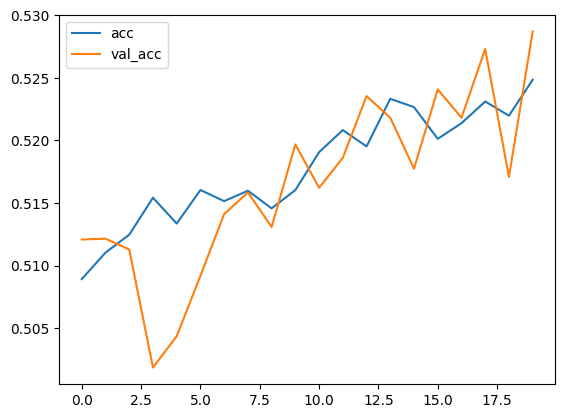

In [36]:
import matplotlib.pyplot as plt
plt.plot(rnn_model.history.history['accuracy'], label = 'acc')
plt.plot(rnn_model.history.history['val_accuracy'], label = 'val_acc')
plt.legend()

### SimpleRNN 그래프 해석
- 정확도가 향상하며 학습을 진행하고 있으니, 정확도가 높은편은 아님 -> 가장 기본적인 RNN 알고리즘을 사용했기 때문
### 모델의 성능 (정확도)를 높이는 방법?
1. 데이터의 질, 양을 향상시키는 방법
2. 더 좋은 성능의 모델을 사용하는 방법

### 기본RNN (SimpleRNN) 의 경우 문장이 길어질수록 앞쪽의 단어를 잃게된다
- SimpleRNN 의 경우 순환의 횟수가 많아질수록 초반에 입력된 단어의 기억데이터가 소실되는 기울기소실현상이 일어남
    - 왜? 활성화 함수로 tanh() 사용하기 때문~
- 문장구성시 초반단어가 후반예측에 영향을 미치는 문장일수록 SimpleRNN 의 경우 학습 결과가 좋지 않게됨.
    - 반짝이는 보석같은 아름다운 _______이(가) 있었다 -> 영화쌤, 용철, 반지, 눈
    - 어제 저녁 하늘에는 반짝이는 보석같이 아름다운 _____이 (가) 있었다 -> 별

### SimpleRNN 단점을 극복한 모델 -> LSTM (Long Short Term Memory)
- 장기기억, 단기기억 관리 계산이 추가된 모델
- 단점: 연산이 복잡, 시간이 오래걸림, 자원의 사용량이 높아짐

### LSTM 단점인 연산의 복잡성을 보완한 모델 -> GRU 모델도 존재

In [37]:
from tensorflow.keras.layers import LSTM, GRU

In [38]:
lstm_model = Sequential()
lstm_model.add(Input(shape = (10, 1))) # (순환횟수, 입력특성)
lstm_model.add(LSTM(units = 64))
lstm_model.add(Dense(units = 1, activation='sigmoid'))

lstm_model.compile(loss = 'binary_crossentropy',
                  optimizer = 'adam',
                  metrics = ['accuracy'])

lstm_model.fit(X_train_vec, y_train, validation_split= 0.2, epochs=20, batch_size = 128)
# 5분

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.5225 - loss: 0.6916 - val_accuracy: 0.5049 - val_loss: 0.6969
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.5302 - loss: 0.6909 - val_accuracy: 0.5244 - val_loss: 0.6907
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.5302 - loss: 0.6903 - val_accuracy: 0.5324 - val_loss: 0.6901
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.5336 - loss: 0.6900 - val_accuracy: 0.5370 - val_loss: 0.6902
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.5335 - loss: 0.6899 - val_accuracy: 0.5336 - val_loss: 0.6899
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.5346 - loss: 0.6895 - val_accuracy: 0.5383 - val_loss: 0.6890
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.5340 - loss: 0.6894 - val_accuracy: 0.5404 - val_loss: 0.6887
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.5363 - loss: 0.6890 - 

In [39]:
gru_model = Sequential()
gru_model.add(Input(shape = (10, 1))) # (순환횟수, 입력특성)
gru_model.add(GRU(units = 64))
gru_model.add(Dense(units = 1, activation='sigmoid'))

gru_model.compile(loss = 'binary_crossentropy',
                  optimizer = 'adam',
                  metrics = ['accuracy'])

gru_model.fit(X_train_vec, y_train, validation_split= 0.2, epochs=20, batch_size = 128)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - accuracy: 0.5165 - loss: 0.6925 - val_accuracy: 0.5278 - val_loss: 0.6906
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.5249 - loss: 0.6913 - val_accuracy: 0.5328 - val_loss: 0.6910
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.5295 - loss: 0.6908 - val_accuracy: 0.5343 - val_loss: 0.6897
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.5302 - loss: 0.6904 - val_accuracy: 0.5336 - val_loss: 0.6899
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.5334 - loss: 0.6898 - val_accuracy: 0.5315 - val_loss: 0.6895
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.5360 - loss: 0.6893 - val_accuracy: 0.5243 - val_loss: 0.6900
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.5365 - loss: 0.6889 - val_accuracy: 0.5327 - val_loss: 0.6887
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.5379 - loss: 0.6885 - 

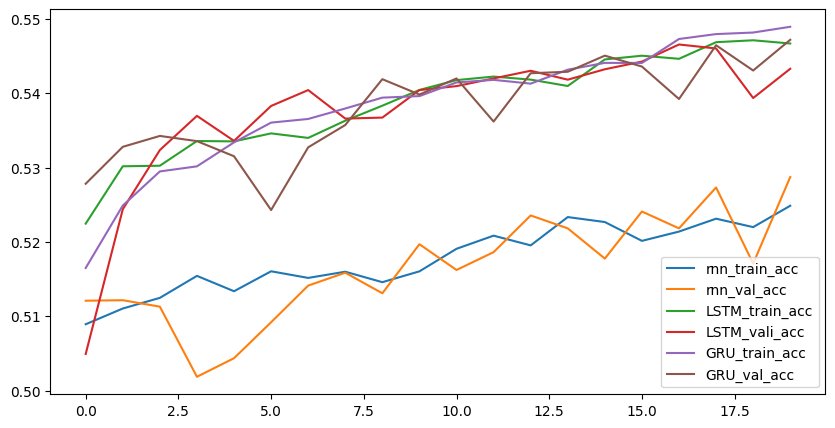

In [40]:
# 결과시각화
plt.figure(figsize=(10,5)) # 가로,세로 길이
# 바닐라 RNN
plt.plot(rnn_model.history.history['accuracy'], label="rnn_train_acc")
plt.plot(rnn_model.history.history['val_accuracy'], label="rnn_val_acc")
# LSTM
plt.plot(lstm_model.history.history['accuracy'], label="LSTM_train_acc")
plt.plot(lstm_model.history.history['val_accuracy'], label="LSTM_vali_acc")
# GRU
plt.plot(gru_model.history.history['accuracy'], label="GRU_train_acc")
plt.plot(gru_model.history.history['val_accuracy'], label="GRU_val_acc")
plt.legend() # 범례
plt.show()

### 워드임베딩 (Word Embedding)
- 자연어처리에서 사용되는 단어를 수치화하는 과정 중 하나
- 의미적 유사성을 반영하여 수치화하는 과정
- 유사한 단어들은 유사한 벡터(방향성)를 가지도록 수치화

In [41]:
# 임베딩 레이어를 추가하여 학습
from tensorflow.keras.layers import Embedding

In [44]:
X_train_vec.shape

(149995, 10, 1)

In [46]:
X_train_vec_pre = np.reshape(X_train_vec,(-1,10))

In [47]:
# RNN, LSTM, GRU 층 이전에 설계하여 사용
embedding_model = Sequential()
embedding_model.add(Embedding(5000,50)) # 단어사전의 크기, 벡터의 크기
embedding_model.add(LSTM(units = 64))
embedding_model.add(Dense(units = 1, activation='sigmoid'))

embedding_model.compile(loss = 'binary_crossentropy',
                  optimizer = 'adam',
                  metrics = ['accuracy'])

embedding_model.fit(X_train_vec_pre, y_train, validation_split= 0.2, epochs=20, batch_size = 128)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - accuracy: 0.7339 - loss: 0.4965 - val_accuracy: 0.7621 - val_loss: 0.4566
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.7672 - loss: 0.4439 - val_accuracy: 0.7627 - val_loss: 0.4569
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.7734 - loss: 0.4309 - val_accuracy: 0.7647 - val_loss: 0.4548
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.7804 - loss: 0.4170 - val_accuracy: 0.7642 - val_loss: 0.4622
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.7860 - loss: 0.4038 - val_accuracy: 0.7646 - val_loss: 0.4703
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.7936 - loss: 0.3903 - val_accuracy: 0.7631 - val_loss: 0.4916
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.8000 - loss: 0.3777 - val_accuracy: 0.7587 - val_loss: 0.5009
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.8063 - loss: 0.3652 - 

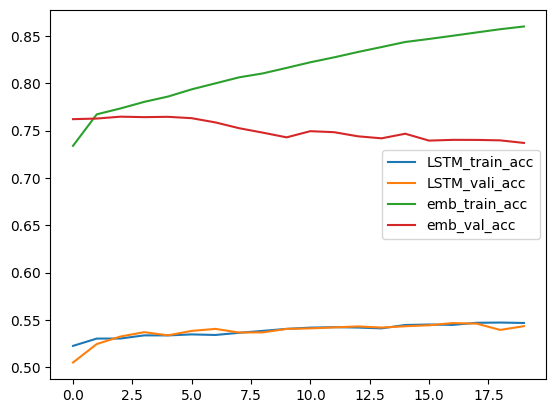

In [48]:
import matplotlib.pyplot as plt

plt.plot(lstm_model.history.history['accuracy'], label="LSTM_train_acc")
plt.plot(lstm_model.history.history['val_accuracy'], label="LSTM_vali_acc")

plt.plot(embedding_model.history.history['accuracy'], label="emb_train_acc")
plt.plot(embedding_model.history.history['val_accuracy'], label="emb_val_acc")
plt.legend() # 범례
plt.show()